# Sentiment Analysis of Musical Instrument Reviews

**Author:** Sirajul Islam

The goal is to predict whether an Amazon review of a musical instrument is **positive**, **neutral** or **negative** from its text, and then serve the model in a small Gradio app.


## 1. Setup

In [1]:
import re
import string
import warnings

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, f1_score, make_scorer, recall_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
SEED = 42
LABELS = ["positive", "neutral", "negative"]
COLORS = {"positive": "#2a9d8f", "neutral": "#e9c46a", "negative": "#e76f51"}

## 2. Data

In [2]:
df = pd.read_csv("Musical_instruments_reviews.csv")
df["reviewText"] = df["reviewText"].fillna("")
print(df.shape)
df[["reviewText", "summary", "overall"]].head()

(10261, 9)


,reviewText,summary,overall
0,"Not much to write about here, but it does exactly what it's supposed to. filters out the pop sounds. now my recordin...",good,5
1,The product does exactly as it should and is quite affordable.I did not realized it was double screened until it arr...,Jake,5
2,"The primary job of this device is to block the breath that would otherwise produce a popping sound, while allowing y...",It Does The Job Well,5
3,Nice windscreen protects my MXL mic and prevents pops. Only thing is that the gooseneck is only marginally able to h...,GOOD WINDSCREEN FOR THE MONEY,5
4,This pop filter is great. It looks and performs like a studio filter. If you're recording vocals this will eliminate...,No more pops when I record my vocals.,5


The data is clean. Only 7 reviews have no text, and those still have a summary.

For the labels, I count 4–5 stars as positive, 3 stars as neutral and 1–2 stars as negative.

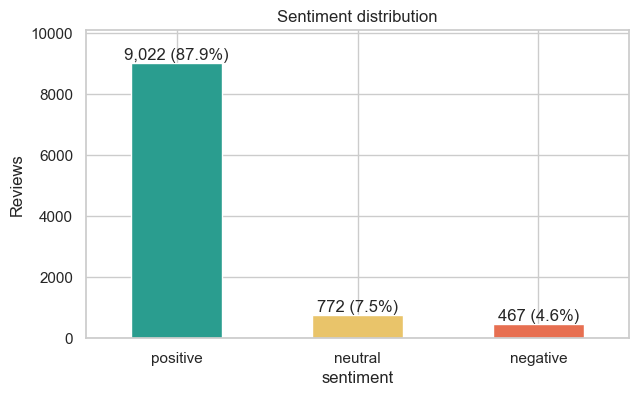

In [3]:
def rating_to_sentiment(r):
    return "positive" if r >= 4 else "negative" if r <= 2 else "neutral"

df["sentiment"] = df["overall"].apply(rating_to_sentiment)

counts = df["sentiment"].value_counts().reindex(LABELS)
ax = counts.plot.bar(color=[COLORS[l] for l in LABELS], rot=0, figsize=(7, 4))
for i, v in enumerate(counts):
    ax.text(i, v + 100, f"{v:,} ({v / len(df):.1%})", ha="center")
ax.set(title="Sentiment distribution", ylabel="Reviews", ylim=(0, counts.max() * 1.12))
plt.show()

Almost 88% of the reviews are positive. A model that always says "positive" would already get 88% accuracy, so I'll use **macro F1** as the main metric. It gives every class the same weight.

In [4]:
neg_words = df["reviewText"].str.lower().str.contains(r"\bnot\b|n't\b|\bno\b|\bnever\b")
neg_words.groupby(df["sentiment"]).mean().reindex(LABELS).round(2).to_frame("has not/no/n't")

,has not/no/n't
sentiment,
positive,0.59
neutral,0.72
negative,0.83


Negation words appear in 83% of negative reviews but only 59% of positive ones. NLTK's stop-word list removes them, though, and my old cleaning turned "does not work" into "work". So this time I keep them.

## 3. Text cleaning

In [5]:
lemmatizer = WordNetLemmatizer()
NLTK_STOP = set(stopwords.words("english"))

# Old version, kept only for comparison
def clean_text_v1(text):
    text = text.lower().translate(str.maketrans("", "", string.punctuation))
    return " ".join(lemmatizer.lemmatize(w) for w in word_tokenize(text) if w not in NLTK_STOP)

# New version: expands n't, keeps negations, drops numbers/URLs
FRAGMENTS = {"ain", "aren", "couldn", "didn", "doesn", "don", "hadn", "hasn", "haven", "isn",
             "mightn", "mustn", "needn", "shan", "shouldn", "wasn", "weren", "won", "wouldn"}
STOP = {w for w in NLTK_STOP if w not in {"no", "not", "nor", "never"} and "n't" not in w and w not in FRAGMENTS}

def clean_text(text):
    text = text.lower().replace("\u2019", "'")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\bcan't\b|\bcannot\b", "can not", text)
    text = re.sub(r"\bwon't\b", "will not", text)
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return " ".join(lemmatizer.lemmatize(w) for w in text.split() if w not in STOP and len(w) > 1)

examples = ["This tuner does not work at all.", "I wouldn't recommend these strings.", "No hum, no noise, great cable!"]
pd.DataFrame({"text": examples,
              "old": [clean_text_v1(t) for t in examples],
              "new": [clean_text(t) for t in examples]})

,text,old,new
0,This tuner does not work at all.,tuner work,tuner not work
1,I wouldn't recommend these strings.,wouldnt recommend string,would not recommend string
2,"No hum, no noise, great cable!",hum noise great cable,no hum no noise great cable


I also add the review summary in front of the text. Summaries like "Great cable" or "Plug slips right out of any jack" say a lot in a few words.

In [6]:
def combine(summary, review):
    summary, review = (summary or "").strip(), (review or "").strip()
    if not summary:
        return review
    return (summary + (" " if summary[-1] in ".!?" else ". ") + review).strip()

df["full_text"] = [combine(s, r) for s, r in zip(df["summary"], df["reviewText"])]

df["text_v1"] = df["reviewText"].apply(clean_text_v1)      # old cleaning, review only
df["text_full_v1"] = df["full_text"].apply(clean_text_v1)  # old cleaning, summary + review
df["text_full"] = df["full_text"].apply(clean_text)        # new cleaning, summary + review
df[["full_text", "text_full"]].head(3)

,full_text,text_full
0,"good. Not much to write about here, but it does exactly what it's supposed to. filters out the pop sounds. now my re...",good not much write exactly supposed filter pop sound recording much crisp one lowest price pop filter amazon might ...
1,Jake. The product does exactly as it should and is quite affordable.I did not realized it was double screened until ...,jake product exactly quite affordable not realized double screened arrived even better expected added bonus one scre...
2,It Does The Job Well. The primary job of this device is to block the breath that would otherwise produce a popping s...,job well primary job device block breath would otherwise produce popping sound allowing voice pas no noticeable redu...


## 4. Train/test split

I use a stratified 80/20 split. The test set is only touched once, at the end. Everything before that uses 5-fold cross-validation on the training set, and every step sits inside a pipeline so nothing leaks between folds.

In [7]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["sentiment"], random_state=SEED)
y_train, y_test = train_df["sentiment"], test_df["sentiment"]
print(f"train: {len(train_df):,}   test: {len(test_df):,}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {
    "macro_f1": "f1_macro",
    "neutral_f1": make_scorer(f1_score, labels=["neutral"], average="macro"),
    "negative_f1": make_scorer(f1_score, labels=["negative"], average="macro"),
    "accuracy": "accuracy",
}

def cv_scores(pipe, col="text_full"):
    s = cross_validate(pipe, train_df[col], y_train, cv=cv, scoring=scoring, n_jobs=-1)
    return {m: s[f"test_{m}"].mean() for m in scoring}

def tfidf(**kw):
    return TfidfVectorizer(**{"ngram_range": (1, 2), "min_df": 2, "sublinear_tf": True, **kw})

train: 8,208   test: 2,053


## 5. Model comparison

In [8]:
%%time
models = {
    "Always 'positive'": (Pipeline([("tfidf", TfidfVectorizer()), ("clf", DummyClassifier())]), "text_full"),
    "Old: Naive Bayes": (Pipeline([("tfidf", TfidfVectorizer()), ("clf", MultinomialNB())]), "text_v1"),
    "Old: oversampling + SVM": (ImbPipeline([("tfidf", TfidfVectorizer()), ("ros", RandomOverSampler(random_state=SEED)),
                                            ("clf", LinearSVC(random_state=SEED))]), "text_v1"),
    "Complement NB": (Pipeline([("tfidf", tfidf()), ("clf", ComplementNB())]), "text_full"),
    "SVM + class weights": (Pipeline([("tfidf", tfidf()), ("clf", LinearSVC(class_weight="balanced", random_state=SEED))]), "text_full"),
    "LogReg + oversampling": (ImbPipeline([("tfidf", tfidf()), ("ros", RandomOverSampler(random_state=SEED)),
                                          ("clf", LogisticRegression(max_iter=3000))]), "text_full"),
    "LogReg + class weights": (Pipeline([("tfidf", tfidf()), ("clf", LogisticRegression(class_weight="balanced", max_iter=3000))]), "text_full"),
}

comparison = pd.DataFrame({name: cv_scores(pipe, col) for name, (pipe, col) in models.items()}).T
comparison.sort_values("macro_f1", ascending=False).round(3)

/Users/mdsirajulislam/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/mdsirajulislam/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/mdsirajulislam/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/mdsirajulislam/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/mdsirajulislam/Library/Py

CPU times: user 157 ms, sys: 118 ms, total: 275 ms
Wall time: 10.6 s


,macro_f1,neutral_f1,negative_f1,accuracy
LogReg + class weights,0.584,0.354,0.461,0.870
LogReg + oversampling,0.578,0.337,0.454,0.882
SVM + class weights,0.515,0.254,0.344,0.892
Old: oversampling + SVM,0.474,0.214,0.289,0.841
Complement NB,0.316,0.000,0.011,0.880
Always 'positive',0.312,0.000,0.000,0.879
Old: Naive Bayes,0.312,0.000,0.000,0.879


- Plain Naive Bayes scores exactly the same as always predicting "positive", so it never predicts anything else. That's where my old 88% came from.
- The old SVM approach is around 0.47 macro F1 once it's evaluated properly.
- **Logistic regression with class weights is the best model.** It also gives probabilities, which I use in the app.

### Which changes helped?

In [9]:
steps = [
    ("old text, single words", "text_v1",      dict(ngram_range=(1, 1), min_df=1, sublinear_tf=False)),
    ("+ summary",              "text_full_v1", dict(ngram_range=(1, 1), min_df=1, sublinear_tf=False)),
    ("+ bigrams",              "text_full_v1", dict(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("+ negations kept",       "text_full",    dict(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
]
ablation = {
    name: cv_scores(Pipeline([("tfidf", TfidfVectorizer(**p)),
                              ("clf", LogisticRegression(class_weight="balanced", max_iter=3000))]), col)
    for name, col, p in steps
}
pd.DataFrame(ablation).T[["macro_f1", "neutral_f1", "negative_f1"]].round(3)

,macro_f1,neutral_f1,negative_f1
"old text, single words",0.485,0.241,0.320
+ summary,0.536,0.313,0.387
+ bigrams,0.572,0.336,0.445
+ negations kept,0.584,0.354,0.461


The summary gave the biggest jump, and bigrams were next. Keeping negations helped less than I expected (about +0.01). Negative reviews usually have other clues like *broke* or *returned*, so the model doesn't rely on "not" as much as I thought.

## 6. Tuning

In [10]:
%%time
pipe = Pipeline([("tfidf", TfidfVectorizer(sublinear_tf=True)),
                 ("clf", LogisticRegression(class_weight="balanced", max_iter=3000))])
grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 3],
    "clf__C": [0.25, 0.5, 1, 2],
}
search = GridSearchCV(pipe, grid, cv=cv, scoring="f1_macro", n_jobs=-1)
search.fit(train_df["text_full"], y_train)
print(search.best_params_, f"CV macro F1 = {search.best_score_:.3f}")

{'clf__C': 0.5, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)} CV macro F1 = 0.585
CPU times: user 4.73 s, sys: 1.93 s, total: 6.67 s
Wall time: 17.2 s


CV macro F1 is about 0.59. That's a lot lower than the old 0.9996, but this time it's an honest number. The top settings were all very close to each other, so the tuning didn't change much.

## 7. Test set results

In [11]:
model = search.best_estimator_
pred = model.predict(test_df["text_full"])

old = clone(models["Old: oversampling + SVM"][0]).fit(train_df["text_v1"], y_train)
old_pred = old.predict(test_df["text_v1"])

def summary(y, p):
    rec = recall_score(y, p, labels=LABELS, average=None)
    return {"accuracy": accuracy_score(y, p), "macro F1": f1_score(y, p, average="macro"),
            "balanced acc": balanced_accuracy_score(y, p),
            "neutral recall": rec[1], "negative recall": rec[2]}

pd.DataFrame({"old approach": summary(y_test, old_pred), "final model": summary(y_test, pred)}).round(3)

,old approach,final model
accuracy,0.843,0.864
macro F1,0.509,0.611
balanced acc,0.502,0.643
neutral recall,0.252,0.465
negative recall,0.333,0.548


              precision    recall  f1-score   support

    positive      0.953     0.915     0.933      1805
     neutral      0.341     0.465     0.393       155
    negative      0.468     0.548     0.505        93

    accuracy                          0.864      2053
   macro avg      0.587     0.643     0.611      2053
weighted avg      0.885     0.864     0.873      2053



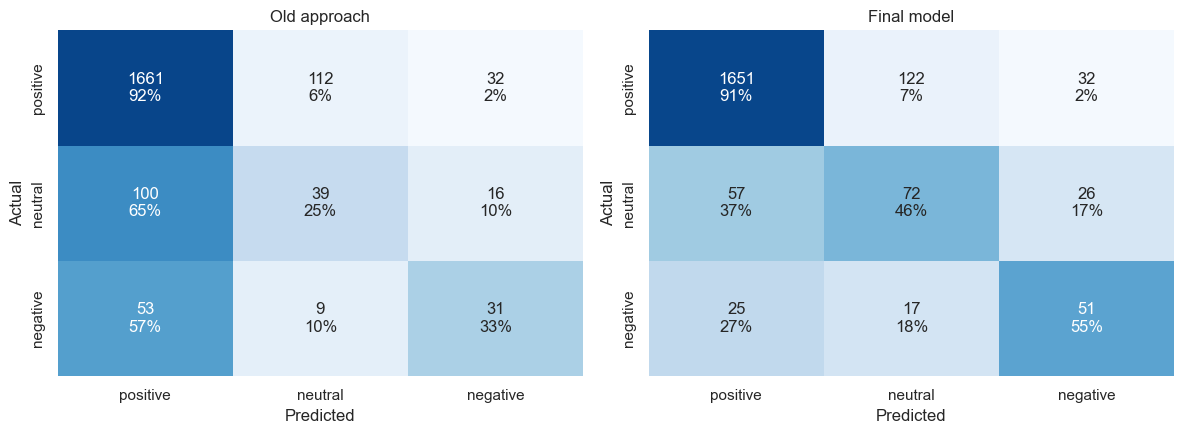

In [12]:
print(classification_report(y_test, pred, labels=LABELS, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (title, p) in zip(axes, [("Old approach", old_pred), ("Final model", pred)]):
    cm = confusion_matrix(y_test, p, labels=LABELS)
    pct = cm / cm.sum(axis=1, keepdims=True)
    annot = [[f"{n}\n{q:.0%}" for n, q in zip(rn, rq)] for rn, rq in zip(cm, pct)]
    sns.heatmap(pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set(title=title, xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.show()

On unseen reviews the final model catches 55% of negative reviews (up from 33%) and 46% of neutral ones (up from 25%). Macro F1 goes from 0.51 to 0.61, and accuracy goes up slightly too.

Neutral is still the weakest class. The most common mistake is a positive review with a complaint in it getting labelled neutral.

## 8. What the model learned

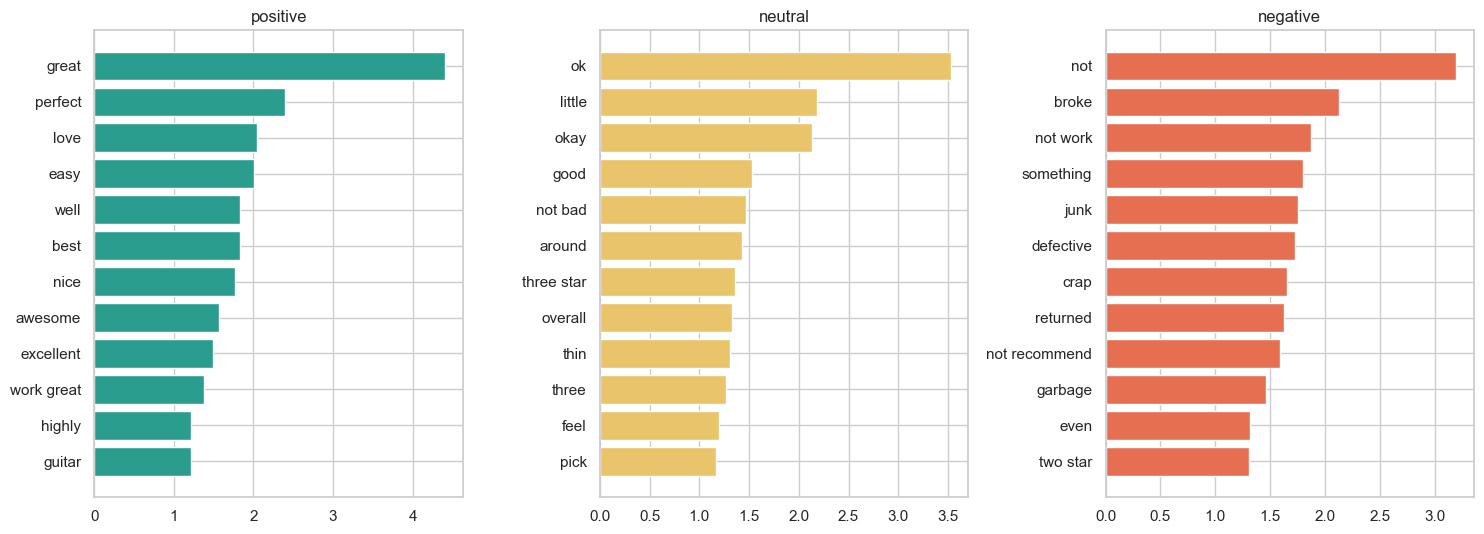

In [13]:
vec, clf = model.named_steps["tfidf"], model.named_steps["clf"]
words = vec.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, label in zip(axes, LABELS):
    coef = clf.coef_[list(clf.classes_).index(label)]
    top = np.argsort(coef)[-12:]
    ax.barh(words[top], coef[top], color=COLORS[label])
    ax.set_title(label)
plt.tight_layout()
plt.show()

These make sense. *great*, *perfect* and *love* point to positive; *ok*, *okay* and *not bad* point to neutral; *not*, *broke*, *not work* and *defective* point to negative. Some reviewers literally write "three stars" in their summary, and the model picked that up too.

In [14]:
errors = test_df.assign(pred=pred, conf=model.predict_proba(test_df["text_full"]).max(axis=1))
errors = errors[errors["pred"] != errors["sentiment"]].sort_values("conf", ascending=False)
errors[["overall", "sentiment", "pred", "conf", "full_text"]].head(5).round(2)

,overall,sentiment,pred,conf,full_text
2812,3,neutral,positive,0.84,Great... ...strings I use D'Addario strings on my acoustic and electric guitars as well they are great. They have a...
6468,3,neutral,positive,0.77,Nice starter Ukulele. There seems to be a trend in using a Ukulele in modern music these days. A guitar player for 2...
2583,3,neutral,positive,0.74,good fit. Very tight fit which is great for your stationary mic .It hold the mic with no concerns of the mic falling...
9348,4,positive,neutral,0.69,Scarlett 2i2 - the start of something great. I'll start off by saying that I've had this interface for about 6 month...
7998,3,neutral,negative,0.68,Avoid if Sold by Music123!!! Let me start by saying that I never even opened these. I've given it a 3 star merely ou...


Many of the confident mistakes are reviews where the text and the star rating don't agree, such as a glowing review with 3 stars. No text model can get those right. The rest are mixed reviews ("good, but..."), where a transformer model would probably do better.

## 9. Save the model

In [15]:
final_model = clone(model).fit(df["text_full"], df["sentiment"])   # refit on all data
joblib.dump(final_model, "sentiment_model.joblib", compress=3)
print("saved sentiment_model.joblib")

saved sentiment_model.joblib


## 10. Gradio app

In [16]:
import gradio, huggingface_hub
print(gradio.__version__, huggingface_hub.__version__)

4.44.1 0.36.2


In [17]:
import gradio as gr

def predict(summary, review):
    text = clean_text(combine(summary, review))
    if not text:
        return {}
    probs = final_model.predict_proba([text])[0]
    return {label: float(p) for label, p in zip(final_model.classes_, probs)}

for s, r in [("", "Doesn't work with my amp at all. Would not recommend."),
             ("", "It's okay. Sound is fine, nothing special."),
             ("Love it", "Best strings I've used, bright tone and they stay in tune.")]:
    print(max(predict(s, r).items(), key=lambda kv: kv[1]), "<-", r)

('negative', 0.8627663835074274) <- Doesn't work with my amp at all. Would not recommend.
('neutral', 0.8299926919844256) <- It's okay. Sound is fine, nothing special.
('positive', 0.9185122357852369) <- Best strings I've used, bright tone and they stay in tune.


In [18]:
demo = gr.Interface(
    fn=predict,
    inputs=[gr.Textbox(label="Review title (optional)"),
            gr.Textbox(label="Review", lines=5, placeholder="Type a review...")],
    outputs=gr.Label(label="Sentiment", num_top_classes=3),
    examples=[["Works perfectly", "Solid build, great sound, and it arrived early."],
              ["Meh", "Fine for practice, but the cable is short and the knob is scratchy."],
              ["Broke in a week", "The jack came loose after a week and now it crackles."]],
    title="Musical Instrument Review Sentiment",
    allow_flagging="never",
    analytics_enabled=False,
)
demo.launch()

Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.
